# График зависимости min(GOF_VR, GOF_AFT) -> Exhumed_thickness

In [223]:
from typing import Literal
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from scipy.interpolate import griddata

import pathlib

In [224]:
def drag_fig(
    filepath: str,
    figtype: Literal["min_gof", "max_gof"] = "min_gof",
    min_gof: float = 0.6,
    max_heatflow: float = 75.0,
    save_path: str = "./fig.png",
):
    assert pathlib.Path(
        filepath
    ).exists(), f"Указанный файл не найден: {filepath}"

    # 1. Загрузка данных
    df = pd.read_csv(filepath, skipinitialspace=True)
    df.columns = df.columns.str.strip()

    # 2. Извлечение данных
    x_raw = df["exhumed_thicknesses_0"].values  # эрозия, м

    # Парсинг теплового потока
    y_raw = np.array(
        [
            float(hf_str.strip("[]").split()[0]) * 1000
            for hf_str in df["heatflow_history"]
        ]
    )

    # Целевая переменная: min(GOF_VR, GOF_AFT)
    z_raw = (
        np.minimum(df["vr_gof"].values, df["aft_age_gof"].values)
        if figtype == "min_gof"
        else np.maximum(df["vr_gof"].values, df["aft_age_gof"].values)
    )

    # 3. Уникальные значения
    x_unique = np.sort(
        df["exhumed_thicknesses_0"].unique()
    )  # [500, 750, 1000, 1250]
    y_unique = np.sort(np.unique(y_raw))  # [68, 70, ..., 82]

    # 4. Создание плотной сетки, покрывающей ВСЮ область данных
    X, Y = np.meshgrid(
        np.linspace(x_unique.min(), x_unique.max(), 200),
        np.linspace(y_unique.min(), y_unique.max(), 200),
    )

    # 5. Интерполяция
    Z = griddata(
        points=(x_raw, y_raw), values=z_raw, xi=(X, Y), method="linear"
    )

    # 6. Уровни цвета от 0.0 до 1.0 с шагом
    levels = np.arange(0.0, 1.01, 0.2)

    # 7. Построение
    plt.figure(figsize=(12, 8))
    contourf = plt.contourf(
        X, Y, Z, levels=levels, cmap="viridis", extend="both"
    )

    # Красные изолинии (опционально)
    contours = plt.contour(
        X, Y, Z, levels=[0.5, 0.6, 0.7], colors="red", linewidths=1.2
    )
    plt.clabel(contours, fmt="%.1f", fontsize=9)

    # Выделение областей с целевым диапазоном GOF и Heatflow
    mask = (Z > min_gof) & (Y < max_heatflow)
    # Вариант 1: закрасить область
    plt.contourf(
        X,
        Y,
        mask,
        levels=[0.5, 1],
        colors=["none", "green"],
        alpha=0.1,
        hatches=["///"],
    )

    # Вариант 2: только контур границы
    # plt.contour(
    #     X, Y, mask.astype(int), levels=[0.5], colors="green", linewidths=2
    # )

    # Серые пунктирные линии по значениям эрозии
    for th in x_unique:
        plt.axvline(
            x=th, color="gray", linestyle=":", linewidth=1.5, alpha=0.8
        )

    # Оформление
    plt.xlabel("Суммарная мощность эксгумации (м)", fontsize=12)
    plt.ylabel("Тепловой поток (мВт м$^{-2}$)", fontsize=12)
    # plt.title("Скважина KDK-01", loc="left", fontweight="bold", fontsize=14)
    plt.colorbar(
        contourf,
        ticks=levels,
        label=(
            ("мин" if figtype == "min_gof" else "макс")
            + "(К$_{согл.VR}$, К$_{согл.AFT}$)"
        ),
    )

    # 🔥 Заполняем ВСЮ область данными:
    plt.xlim(x_unique.min(), x_unique.max())
    plt.ylim(y_unique.min(), y_unique.max())

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

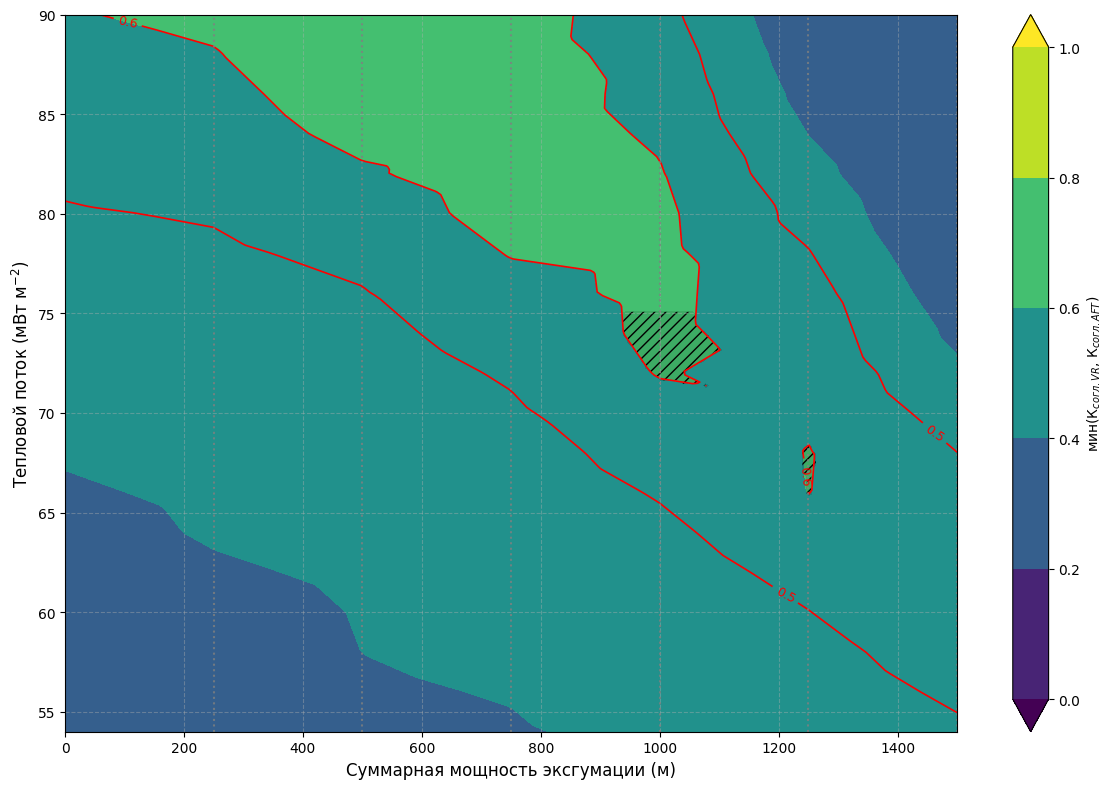

In [225]:
# Результаты расчетов с исключенными аномальными зернами AFT в KDK-01
drag_fig(
    "../model_output/without_anomalies/publishable_results/model_results_2-2-2026_KDK-01_ms0-133_final.csv",
    "min_gof",
    save_path="./without_anomalies.png",
)

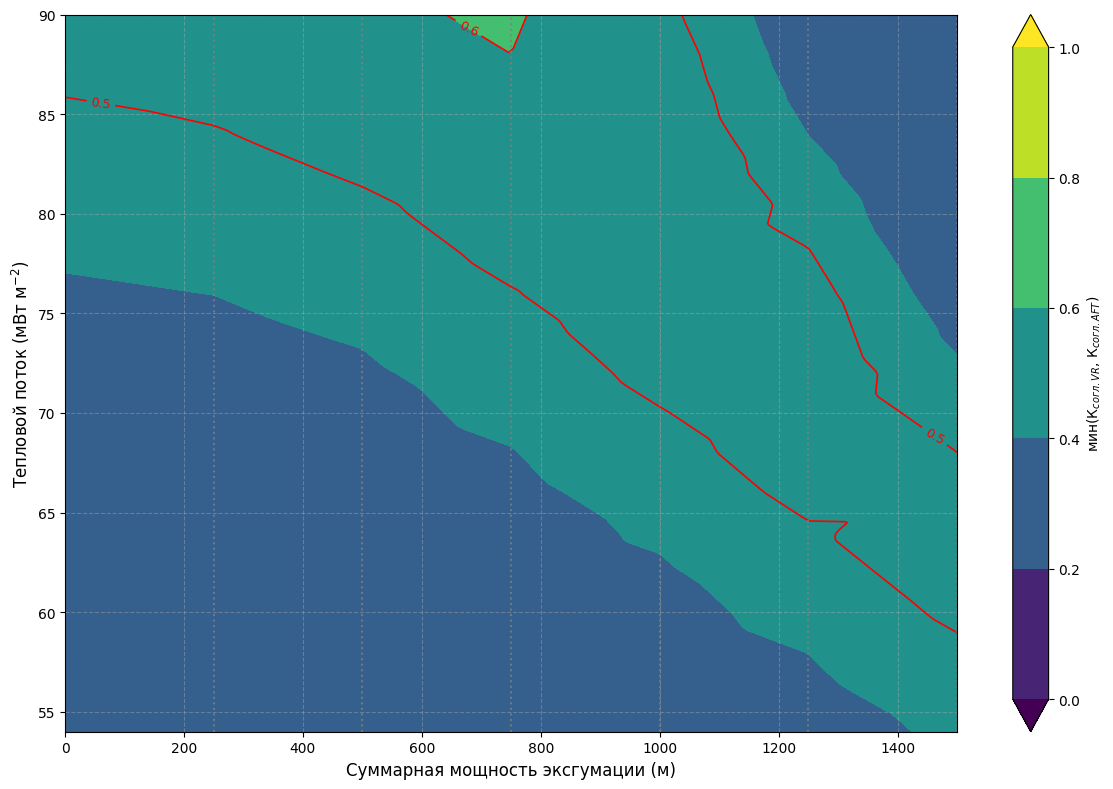

In [226]:
# Результаты расчетов с аномальными зернами AFT в KDK-01
drag_fig(
    "../model_output/with_anomalies/publishable_results/model_results_2-2-2026_KDK-01_ms0-133_final.csv",
    "min_gof",
    save_path="./with_anomalies.png",
)